In [7]:
import os

os.chdir(r"C:\Users\saraa\Assignment2-ML")
print(os.getcwd())
print(os.listdir())


C:\Users\saraa\Assignment2-ML
['Assignment-2.ipynb', 'StudentsPerformance.csv.xlsx']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [8]:
df = pd.read_excel("StudentsPerformance.csv.xlsx")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA


In [10]:
import os

os.chdir(r"C:\Users\saraa\Assignment2-ML")
print(os.getcwd())
print(os.listdir())

C:\Users\saraa\Assignment2-ML
['Assignment-2.ipynb', 'StudentsPerformance.csv.xlsx']


In [11]:
df = pd.read_excel("StudentsPerformance.csv.xlsx")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [13]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [ ]:
## Task 1: Identify Data Quality Issues

In [15]:
# Check dataset shape
df.shape

(1000, 8)

In [16]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [17]:
# Check missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [18]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [19]:
# Summary statistics for numerical columns
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [20]:
# Check categorical values
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print()

gender
['female' 'male']

race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']

parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

lunch
['standard' 'free/reduced']

test preparation course
['none' 'completed']



The dataset contains 1000 rows and 8 columns. There are 5 categorical columns and 3 numerical columns. The numerical columns are math score, reading score, and writing score. The dataset was checked for missing values, duplicate rows, data types, and unusual values. The missing value check showed that there are no missing values in the dataset.

The duplicate row check showed that there are no duplicated records in the dataset.

## Task 2: Apply Missing Value Strategy

In [21]:
# Make a copy of the dataset
df_clean = df.copy()

# Separate numerical and categorical columns
numeric_cols = df_clean.select_dtypes(include=np.number).columns
categorical_cols = df_clean.select_dtypes(include="object").columns

numeric_cols, categorical_cols

(Index(['math score', 'reading score', 'writing score'], dtype='object'),
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course'],
       dtype='object'))

In [23]:
# Apply median imputation for numerical columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Apply mode imputation for categorical columns
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [24]:
print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [25]:
df_clean.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Task 3: Detect and Handle Outliers Using IQR

In [26]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns
numeric_cols

Index(['math score', 'reading score', 'writing score'], dtype='object')

In [27]:
# Detect outliers using IQR
outlier_summary = {}

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    
    outlier_summary[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers)
    }

outlier_summary_df = pd.DataFrame(outlier_summary).T
outlier_summary_df

,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
math score,57.00,77.0,20.00,27.000,107.000,8.0
reading score,59.00,79.0,20.00,29.000,109.000,6.0
writing score,57.75,79.0,21.25,25.875,110.875,5.0


In [30]:
# Handle outliers by capping them to the lower and upper bounds
df_no_outliers = df_clean.copy()

for col in numeric_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_no_outliers[col] = np.where(
        df_no_outliers[col] < lower_bound,
        lower_bound,
        np.where(df_no_outliers[col] > upper_bound, upper_bound, df_no_outliers[col])
    )

In [31]:
df_no_outliers[numeric_cols].describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,66.165000,69.201000,68.094375
std,14.922414,14.503481,15.068368
min,27.000000,29.000000,25.875000
25%,57.000000,59.000000,57.750000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


The IQR method was used to detect outliers in the numerical columns: math score, reading score, and writing score. IQR is calculated as Q3 - Q1. Any value below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR is considered an outlier.

To handle the outliers, capping was used instead of deleting rows. Values below the lower bound were replaced with the lower bound, and values above the upper bound were replaced with the upper bound. This keeps all 1000 records in the dataset while reducing the effect of extreme values.

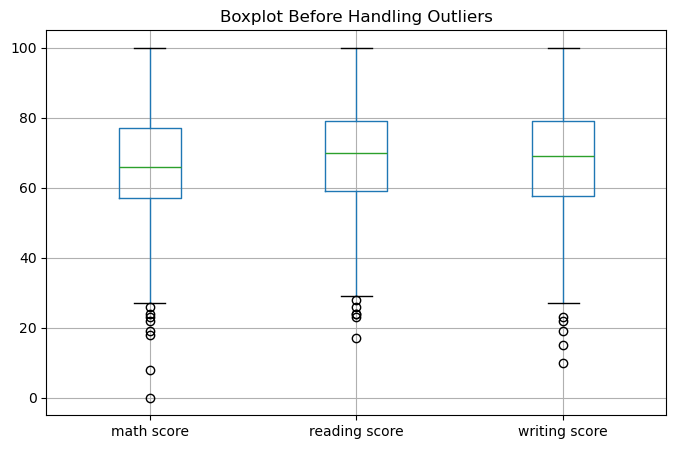

In [32]:
df_clean[numeric_cols].boxplot(figsize=(8,5))
plt.title("Boxplot Before Handling Outliers")
plt.show()

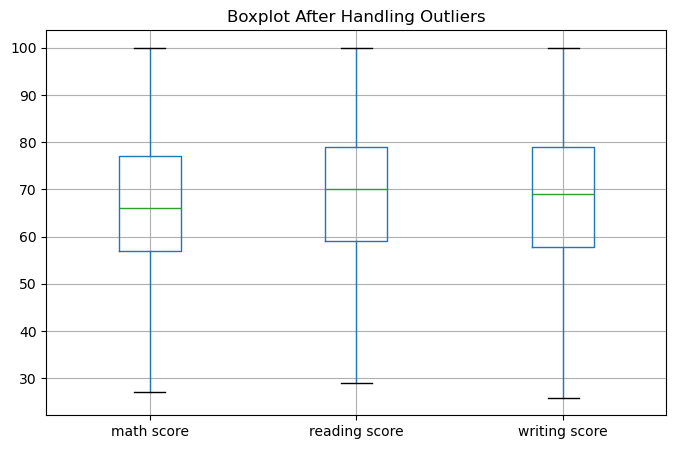

In [33]:
df_no_outliers[numeric_cols].boxplot(figsize=(8,5))
plt.title("Boxplot After Handling Outliers")
plt.show()

## Task 4: Normalize Numerical Features Using Min-Max and Z-score

In [35]:
# Create scalers
minmax_scaler = MinMaxScaler()
zscore_scaler = StandardScaler()

# Make copies of the dataset after outlier handling
df_minmax = df_no_outliers.copy()
df_zscore = df_no_outliers.copy()

# Apply Min-Max normalization
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_no_outliers[numeric_cols])

# Apply Z-score normalization
df_zscore[numeric_cols] = zscore_scaler.fit_transform(df_no_outliers[numeric_cols])

In [36]:
df_minmax.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,0.616438,0.605634,0.649241
1,female,group C,some college,standard,completed,0.575342,0.859155,0.838111
2,female,group B,master's degree,standard,none,0.863014,0.929577,0.905565
3,male,group A,associate's degree,free/reduced,none,0.273973,0.394366,0.244519
4,male,group C,some college,standard,none,0.671233,0.690141,0.662732


In [37]:
df_zscore.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,0.391218,0.193085,0.392118
1,female,group C,some college,standard,completed,0.190078,1.434787,1.321682
2,female,group B,master's degree,standard,none,1.598061,1.779704,1.653669
3,male,group A,associate's degree,free/reduced,none,-1.284952,-0.841667,-1.599804
4,male,group C,some college,standard,none,0.659405,0.606986,0.458515


In [38]:
df_minmax[numeric_cols].describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,0.536507,0.566211,0.569570
std,0.204417,0.204274,0.203283
min,0.000000,0.000000,0.000000
25%,0.410959,0.422535,0.430017
50%,0.534247,0.577465,0.581788
75%,0.684932,0.704225,0.716695
max,1.000000,1.000000,1.000000


In [39]:
df_zscore[numeric_cols].describe()

,math score,reading score,writing score
count,1.000000e+03,1.000000e+03,1.000000e+03
mean,-4.192202e-16,4.689582e-16,5.329071e-17
std,1.000500e+00,1.000500e+00,1.000500e+00
min,-2.625889e+00,-2.773204e+00,-2.803256e+00
25%,-6.144841e-01,-7.037003e-01,-6.868395e-01
50%,-1.106272e-02,5.511779e-02,6.013114e-02
75%,7.264523e-01,6.759690e-01,7.241051e-01
max,2.268529e+00,2.124622e+00,2.118450e+00


Min-Max normalization and Z-score normalization were applied to the numerical columns: math score, reading score, and writing score. Min-Max normalization scales the values between 0 and 1. Z-score normalization standardizes the values so that the mean becomes approximately 0 and the standard deviation becomes approximately 1.

Both normalization methods are important because machine learning and PCA can be affected by differences in feature scales.

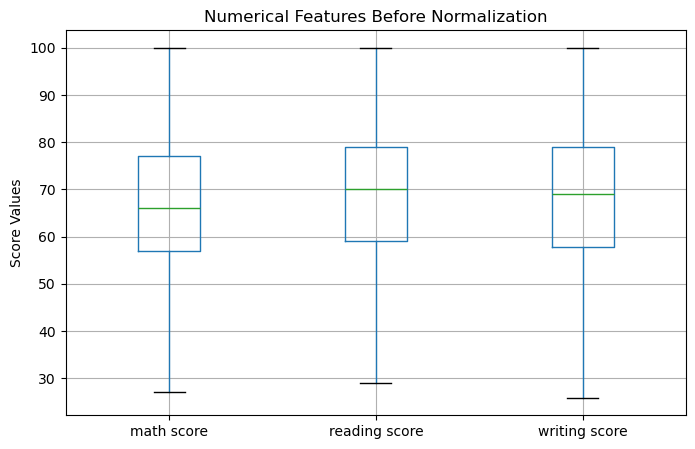

In [40]:
df_no_outliers[numeric_cols].boxplot(figsize=(8,5))
plt.title("Numerical Features Before Normalization")
plt.ylabel("Score Values")
plt.show()

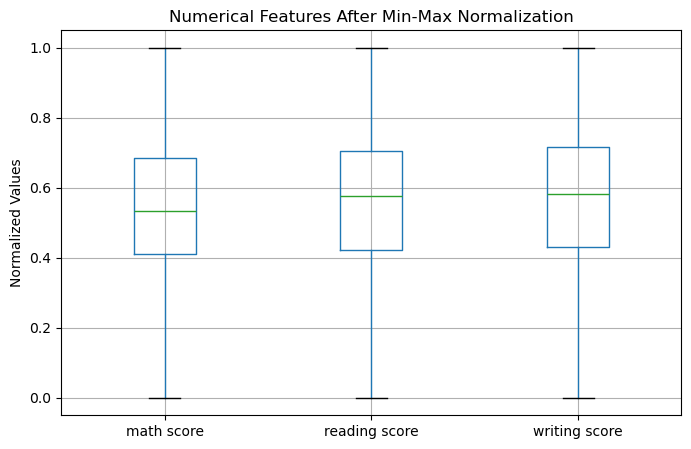

In [41]:
df_minmax[numeric_cols].boxplot(figsize=(8,5))
plt.title("Numerical Features After Min-Max Normalization")
plt.ylabel("Normalized Values")
plt.show()

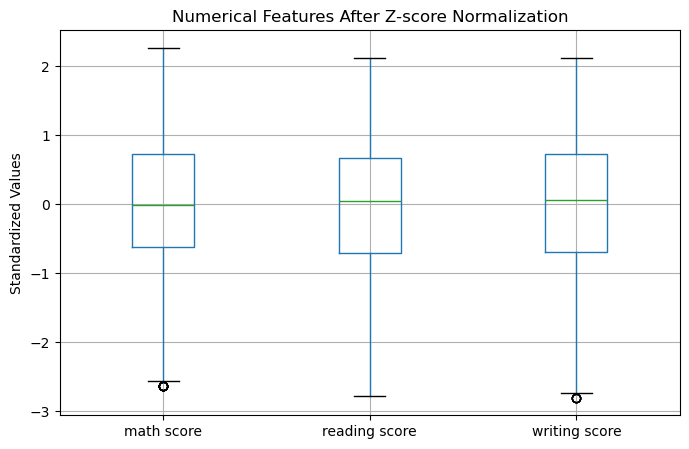

In [42]:
df_zscore[numeric_cols].boxplot(figsize=(8,5))
plt.title("Numerical Features After Z-score Normalization")
plt.ylabel("Standardized Values")
plt.show()

The boxplots show the effect of normalization on the numerical features. Before normalization, the scores were on their original scale. After Min-Max normalization, all numerical values were scaled between 0 and 1. After Z-score normalization, the values were standardized around a mean of 0, making the features more suitable for PCA.

## Task 5: Apply PCA and Interpret Explained Variance

In [43]:
# Apply PCA on Z-score normalized numerical columns
pca = PCA()

pca_result = pca.fit_transform(df_zscore[numeric_cols])

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.90502723, 0.07980602, 0.01516675])

In [44]:
pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

pca_summary

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.905027,0.905027
1,PC2,0.079806,0.984833
2,PC3,0.015167,1.000000


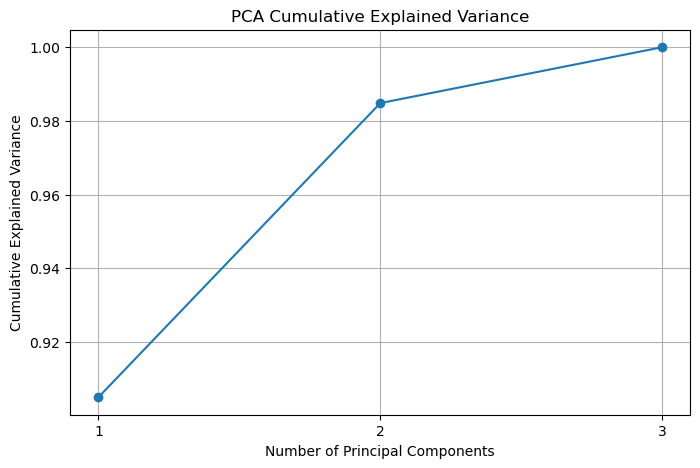

In [46]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained_variance) + 1),
    np.cumsum(explained_variance),
    marker='o'
)

plt.xticks(range(1, len(explained_variance) + 1))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

PCA was applied to the Z-score normalized numerical features: math score, reading score, and writing score. PCA transforms the original features into principal components, where each component explains part of the variance in the dataset.

The explained variance ratio shows how much information is captured by each principal component. The cumulative variance shows the total amount of information retained as more components are included. A higher cumulative variance means that the selected components preserve more information from the original dataset.

In conclusion, PCA shows that two principal components are sufficient for this dataset because they explain approximately 98.48% of the total variance.